Applying convolution to a grayscale image

In [ ]:

from PIL import Image #pillow (https://pillow.readthedocs.io/en/stable/handbook/tutorial.html)
from skimage.io import imread, imshow, show #skimage - scikit-image (https://scikit-image.org/)
import scipy.fftpack as fp #for performing fast fourier tranformation
from scipy import ndimage, misc, signal #ndimage and signal - used for multidimensional image processing, misc- for miscellaneous functions
import imageio #for reading/writing images in multiple formats
import matplotlib.pylab as plt # for plotting and visualizing images
from skimage import data, img_as_float # data - provides the built-in sample images and datsets, img_as_float - converts the image to floating point representation
from skimage.color import rgb2gray # converts the image (RGB) to grayscale
from skimage.transform import rescale # rescale an image by scaling factor
import matplotlib.pylab as pylab # it combines the functionality of pyplot and numpy
import numpy as np # technique for matrix specify functions
import numpy.fft # frequncy domain analysis using numpy functions for performing fast fourier transform
import timeit # measuring execution time of code snippets
import PIL.ImageStat as stat #module for computing image statistics
import cv2 #open cv for advanced image processing and computer vision tasks


In [ ]:
def signaltonoise(a, axis=0, ddof=0): # a is the input array, axis = 0
    a = np.asanyarray(a)
    m = a.mean(axis) #mean value of array a along the axis = 0, which represents the signals
    sd = a.std(axis=axis, ddof=ddof) # used to represnt the noise int the data
    return np.where(sd == 0, 0, m/sd) # where function is used handle the case when standard deviation is zero, the function
                                    # should return 0(as the SNR is undefined or infinite as sd is in denominator) otherwiae it should return
                                    # the m/sd -- which is the signal to noise ratio

0.9921568627450982
(256, 256)


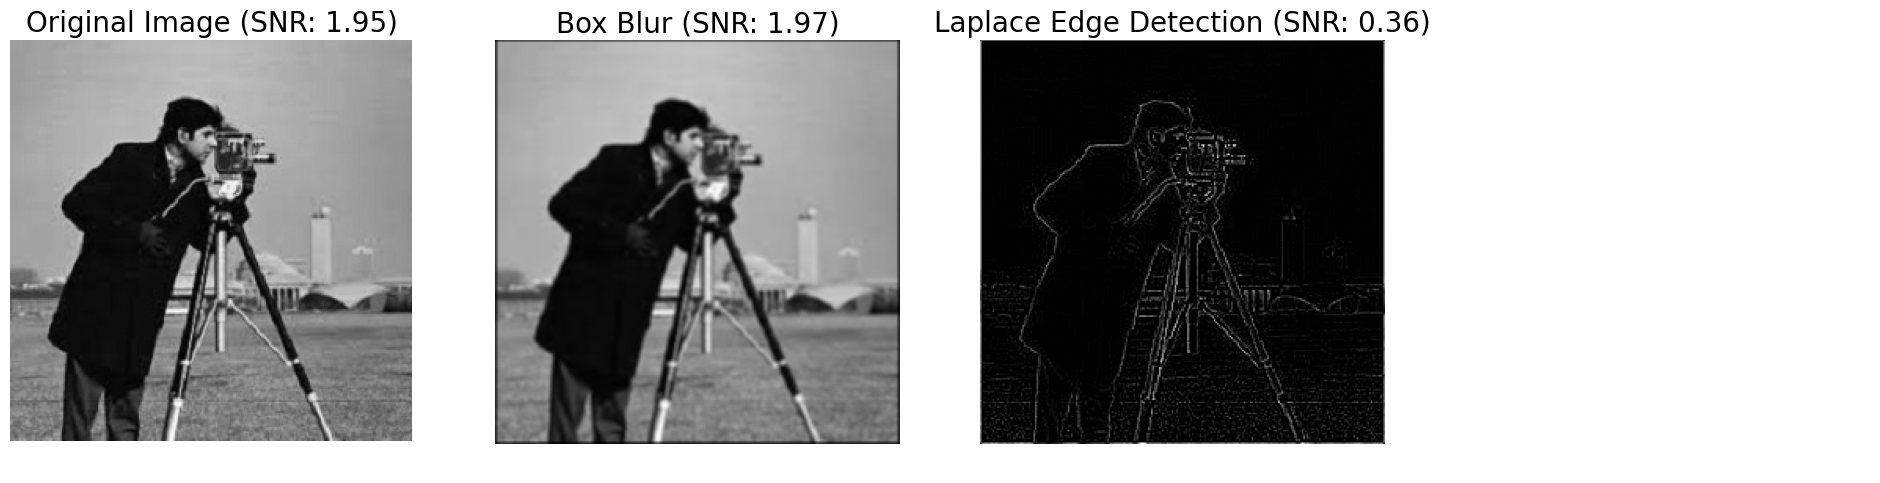

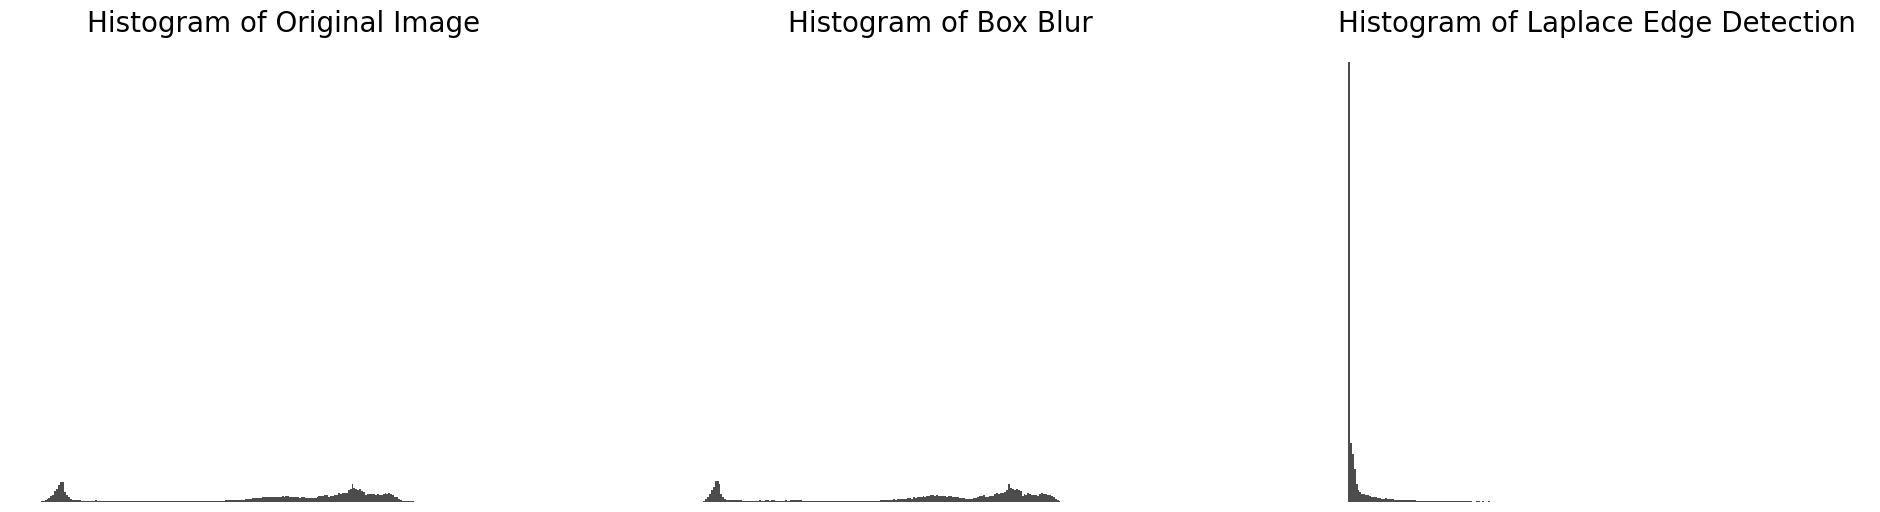

In [ ]:
im = rgb2gray(imread('cameraman.jpg')).astype(float)
print(np.max(im)) # to get the maximum intensity value in the image
print(im.shape) # get the shape of the image
blur_box_kernel = np.ones((3,3)) / 9 #a 3x3 box blur kernel(the new value of the pixel is average of its neighbours)
edge_laplace_kernel = np.array([[0,1,0],[1,-4,1],[0,1,0]]) #laplace kernel used for the edge detection
im_blurred = signal.convolve2d(im, blur_box_kernel)  #convolution 2D using the box blur kernel
im_edges = np.clip(signal.convolve2d(im, edge_laplace_kernel), 0, 1) #edge detection using laplacian kernel (center pixel gets subtracted by surrounding ones to highlight the edges) np.clip is used to ensure that the values are with the range of 0 to 1
fig, axes = pylab.subplots(ncols=4, sharex=True, sharey=True, figsize=(24,6))

# Compute SNR values
original_snr = signaltonoise(im, axis=None)
blurred_snr = signaltonoise(im_blurred, axis=None)
edges_snr = signaltonoise(im_edges, axis=None)

# Display original, blurred, and edge-detected images
axes[0].imshow(im, cmap=pylab.cm.gray)
axes[0].set_title(f'Original Image (SNR: {original_snr:.2f})', size=20)
axes[1].imshow(im_blurred, cmap=pylab.cm.gray)
axes[1].set_title(f'Box Blur (SNR: {blurred_snr:.2f})', size=20)
axes[2].imshow(im_edges, cmap=pylab.cm.gray)
axes[2].set_title(f'Laplace Edge Detection (SNR: {edges_snr:.2f})', size=20)

for ax in axes:
    ax.axis('off')
pylab.show()

# Compute histograms for all three images
axes[3].hist(im.ravel(), bins=256, range=(0, 1), color='black', alpha=0.7)
axes[3].set_title('Histogram of Original Image', size=20)

# Display histograms for blurred and edge-detected images
fig, axes_hist = pylab.subplots(ncols=3, sharex=True, sharey=True, figsize=(24,6))

# Create a histogram for the image 'im' in the first subplot (axes_hist[0])
# Flatten the image into a 1D array using ravel(), then plot pixel intensities
# Use 256 bins to represent the range of pixel values (0-1)
# Set the histogram bars to black color with 70% opacity (alpha=0.7)
axes_hist[0].hist(im.ravel(), bins=256, range=(0, 1), color='black', alpha=0.7)
axes_hist[0].set_title('Histogram of Original Image', size=20)

axes_hist[1].hist(im_blurred.ravel(), bins=256, range=(0, 1), color='black', alpha=0.7)
axes_hist[1].set_title('Histogram of Box Blur', size=20)

axes_hist[2].hist(im_edges.ravel(), bins=256, range=(0, 1), color='black', alpha=0.7)
axes_hist[2].set_title('Histogram of Laplace Edge Detection', size=20)

for ax in axes_hist:
    ax.axis('off')

pylab.show()


Applying convolution to a color (RGB) image

1.0
(1018, 1645, 3)


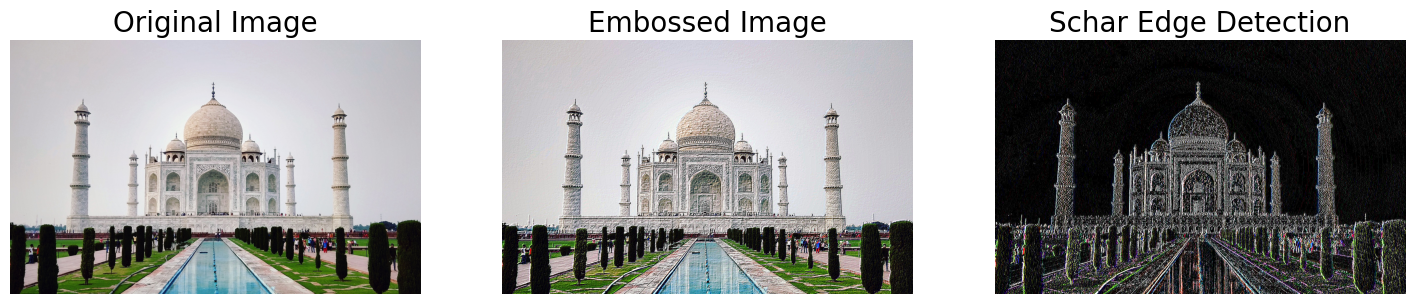

SNR of Original Image: 2.607477702915532
SNR of Embossed Image: 2.240137435721816
SNR of Schar Edge Detection Image: 0.5057046156171853


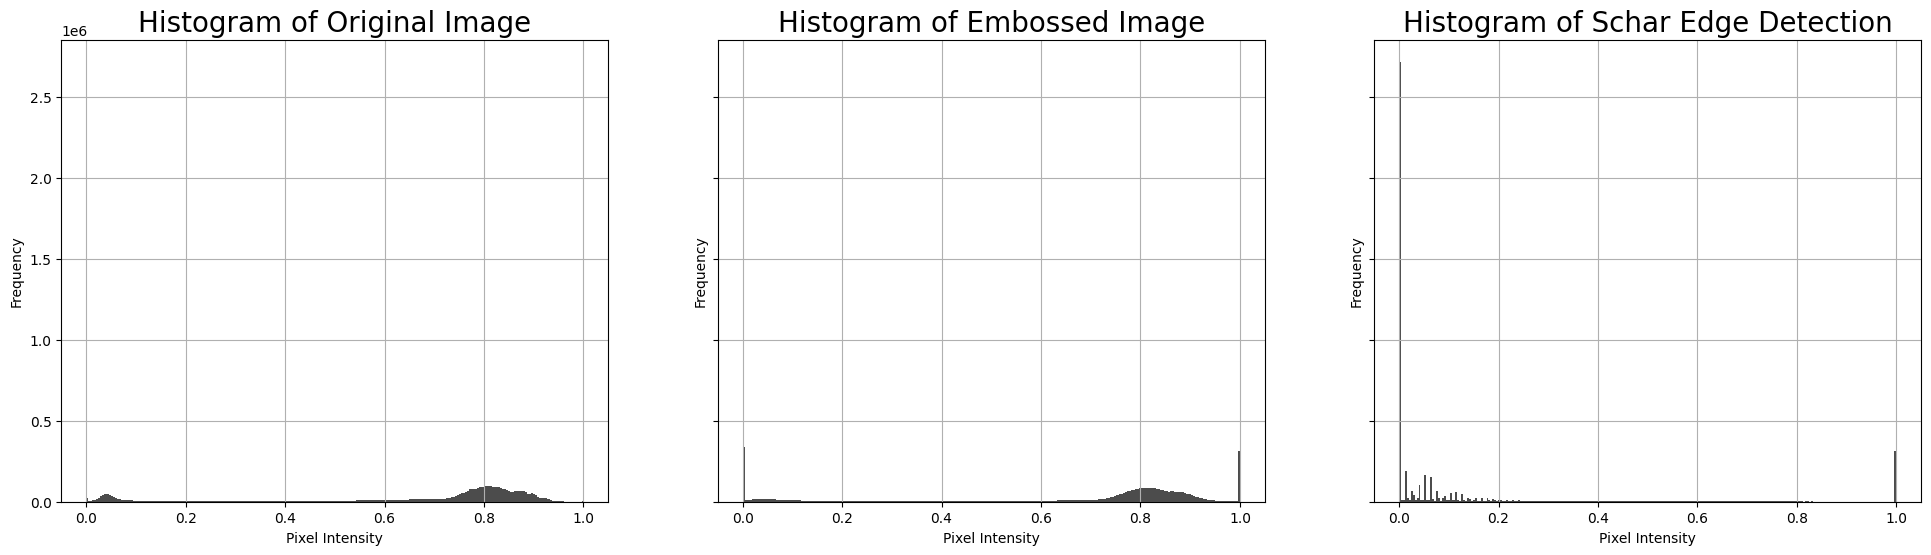

In [ ]:
im = imageio.v2.imread('tajmahal.jpg')/255 # scale each pixel value in [0,1] (normalizating the values for easy application of convolution)
print(np.max(im)) # print the max intensity value
print(im.shape) # shape of the image
emboss_kernel = np.array([[-2,-1,0],[-1,1,1],[0,1,2]]) # making a 3x3 embossing kernel to create a 3D like effect ( by enchancing the highlights and shadows used for cretaing texture affects in the image)
edge_schar_kernel = np.array([[ -3-3j, 0-10j, +3 -3j], [-10+0j, 0+ 0j, +10+0j], [ -3+3j, 0+10j, +3 +3j]]) # schar edge kernel is a complex valued filter for detecting both the horizontal and vertical directions
#initialize the array for storing the filtered images
im_embossed = np.ones(im.shape)
im_edges = np.ones(im.shape)
#apply the emboss filter to each RGB channel separately
for i in range(3):
    im_embossed[...,i] = np.clip(signal.convolve2d(im[...,i], emboss_kernel, mode='same', boundary="symm"),0,1)
#apply the Schar edge filter to each RGB channel separately
for i in range(3):
    im_edges[:,:,i] = np.clip(np.real(signal.convolve2d(im[...,i], edge_schar_kernel, mode='same', boundary="symm")),0,1)
fig, axes = pylab.subplots(ncols=3, figsize=(18, 6))
axes[0].imshow(im)
axes[0].set_title('Original Image', size=20)
axes[1].imshow(im_embossed)
axes[1].set_title('Embossed Image', size=20)
axes[2].imshow(im_edges)
axes[2].set_title('Schar Edge Detection', size=20)
for ax in axes:
    ax.axis('off')
pylab.show()

# Calculate the SNR for the original, embossed, and edge-detected images
snr_original = signaltonoise(im)
snr_embossed = signaltonoise(im_embossed)
snr_edges = signaltonoise(im_edges)

# Print the SNR values for the images
print(f"SNR of Original Image: {np.mean(snr_original)}")
print(f"SNR of Embossed Image: {np.mean(snr_embossed)}")
print(f"SNR of Schar Edge Detection Image: {np.mean(snr_edges)}")

# Create subplots for histograms of the images
fig, axes_hist = pylab.subplots(ncols=3, sharex=True, sharey=True, figsize=(24, 6))

# Histogram for the Original Image
axes_hist[0].hist(im.ravel(), bins=256, range=(0, 1), color='black', alpha=0.7)
axes_hist[0].set_title('Histogram of Original Image', size=20)

# Histogram for the Embossed Image
axes_hist[1].hist(im_embossed.ravel(), bins=256, range=(0, 1), color='black', alpha=0.7)
axes_hist[1].set_title('Histogram of Embossed Image', size=20)

# Histogram for the Edge-detected Image
axes_hist[2].hist(im_edges.ravel(), bins=256, range=(0, 1), color='black', alpha=0.7)
axes_hist[2].set_title('Histogram of Schar Edge Detection', size=20)

# Display histograms
for ax in axes_hist:
    ax.set_xlabel('Pixel Intensity')
    ax.set_ylabel('Frequency')
    ax.grid(True)

pylab.show()

Convolution with SciPy ndimage.convolve

<ipython-input-43-8e47b8e0d23f>:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread('victoria_memorial.png').astype(float)
<ipython-input-40-effe92dd49a5>:5: RuntimeWarning: divide by zero encountered in divide
  return np.where(sd == 0, 0, m/sd) # where function is used handle the case when standard deviation is zero, the function


255.0


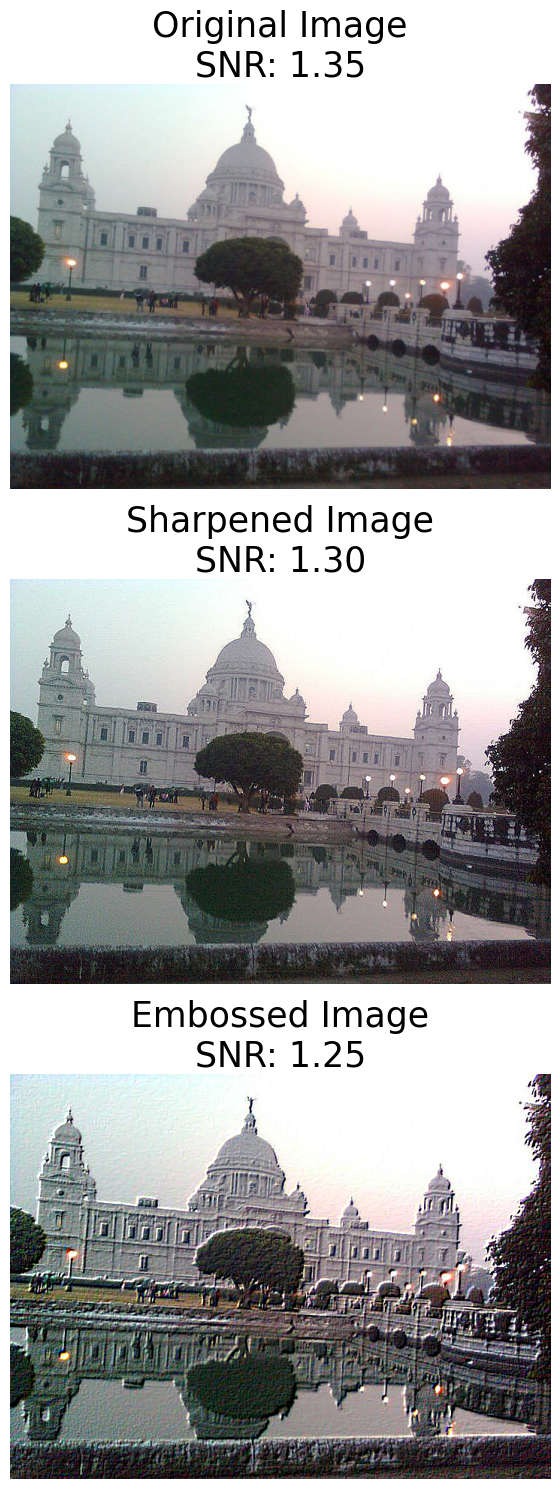

In [ ]:
im = imageio.imread('victoria_memorial.png').astype(float)
print(np.max(im))

# Define the kernels for sharpening and embossing
sharpen_kernel = np.array([0, -1, 0, -1, 5, -1, 0, -1, 0]).reshape((3, 3, 1))  #enchnaces the center pixel value and reduce the surrounding pixel intensity to enhance the edge(it is used to enhance the contrast and sharpness)
emboss_kernel = np.array([[-2,-1,0],[-1,1,1],[0,1,2]]).reshape((3, 3, 1))  #negative values are used to darken one side of the edge and positive value to used to brighten the opposite side to create depth

# Apply the sharpening and embossing filters
im_sharp = ndimage.convolve(im, sharpen_kernel, mode='nearest')    #scipy's ndimage convolution function is used to sharpen the image
im_sharp = np.clip(im_sharp, 0, 255).astype(np.uint8) # clip (0 to 255) and convert to unsigned 8-bit int for display
im_emboss = ndimage.convolve(im, emboss_kernel, mode='nearest') #aapply the embossing filter
im_emboss = np.clip(im_emboss, 0, 255).astype(np.uint8) #clip and convert to unsigned 8-bit int for display

# Calculate the SNR for the original, sharpened, and embossed images
snr_original = signaltonoise(im)
snr_sharpened = signaltonoise(im_sharp)
snr_embossed = signaltonoise(im_emboss)

# Display the images with SNR values in the titles
plt.figure(figsize=(10,15))

# Original Image with SNR in title
plt.subplot(311)
plt.imshow(im.astype(np.uint8))
plt.axis('off')
plt.title(f'Original Image\nSNR: {np.mean(snr_original):.2f}', size=25)

# Sharpened Image with SNR in title
plt.subplot(312)
plt.imshow(im_sharp)
plt.axis('off')
plt.title(f'Sharpened Image\nSNR: {np.mean(snr_sharpened):.2f}', size=25)

# Embossed Image with SNR in title
plt.subplot(313)
plt.imshow(im_emboss)
plt.axis('off')
plt.title(f'Embossed Image\nSNR: {np.mean(snr_embossed):.2f}', size=25)

plt.tight_layout()
plt.show()

Template matching with cross-correlation between the image and template

<ipython-input-44-09fb35e34624>:1: DeprecationWarning: scipy.misc.face has been deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. Dataset methods have moved into the scipy.datasets module. Use scipy.datasets.face instead.
  face_image = misc.face(gray=True) - misc.face(gray=True).mean() #load the sample racoon image in grayscale from miscellaneoeus module of scipy and subtract the mean to get the normalized form


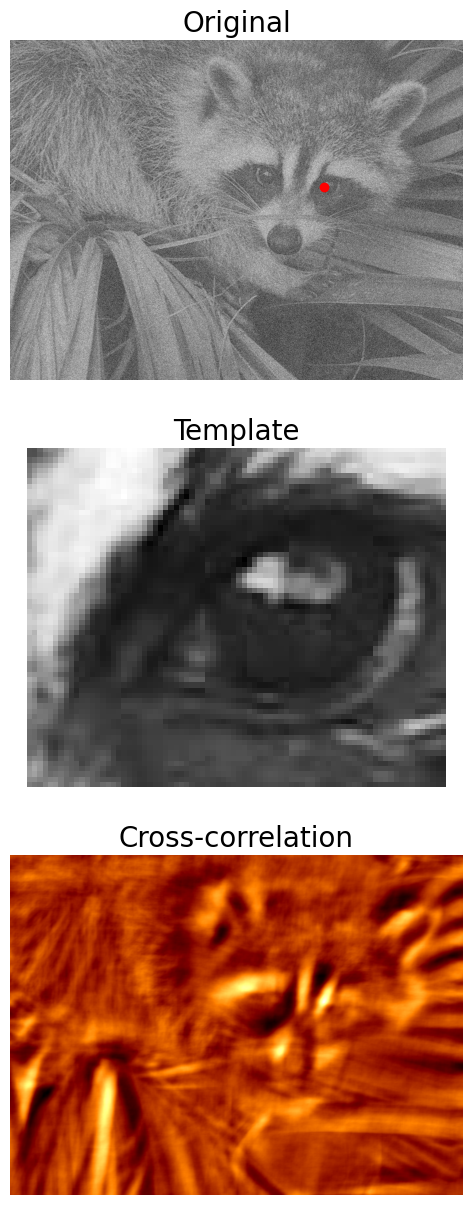

In [ ]:
face_image = misc.face(gray=True) - misc.face(gray=True).mean() #load the sample racoon image in grayscale from miscellaneoeus module of scipy and subtract the mean to get the normalized form
template_image = np.copy(face_image[300:365, 670:750]) # extract right eye region of the image by cropping it and take it as template
template_image -= template_image.mean() #make it normalized
face_image = face_image + np.random.randn(*face_image.shape) * 50 # add random noise(here gaussian noise with standard deviation of 50 is added)
correlation = signal.correlate2d(face_image, template_image, boundary='symm', mode='same') # cross-correlation is performed between the noisy face image and the template image to find the match
# 'boundary=symm' handles the boundaries by mirroring the edges, and 'mode=same' returns a result the same size as the input image
y, x = np.unravel_index(np.argmax(correlation), correlation.shape) # find the match (# the location of the maximum value in the correlation matrix)
# np.argmax() returns the index of the maximum value in the correlation matrix, and np.unravel_index() converts it to (y, x) coordinates
fig, (ax_original, ax_template, ax_correlation) = pylab.subplots(3, 1, figsize=(6, 15))
ax_original.imshow(face_image, cmap='gray') # show the face image in grayscale
ax_original.set_title('Original', size=20)
ax_original.set_axis_off()
ax_template.imshow(template_image, cmap='gray') # show the template image in grayscale
ax_template.set_title('Template', size=20)
ax_template.set_axis_off()
ax_correlation.imshow(correlation, cmap='afmhot') # display the cross-correlation result with a heatmap
ax_correlation.set_title('Cross-correlation', size=20)
ax_correlation.set_axis_off()
ax_original.plot(x, y, 'ro') #mark the position of the best match on the original image with a red dot
fig.show()

Plotting the histograms of pixel values for the RGB channels of an image

In [ ]:
im = Image.open("parrot.png")

Computing the basic statistics of an image

In [ ]:
s = stat.Stat(im)
print(s.extrema) # maximum and minimum pixel values for each channel R, G, B
print(s.count) #print totalno. of pixels in the image in each channel
print(s.mean) #print the average pixel value for each channel
print(s.median) #median pixel value for each channel
print(s.stddev) #standard deviation for each channel

[(0, 255), (0, 255), (0, 253)]
[154020, 154020, 154020]
[125.41716010907675, 124.4158940397351, 68.46314764316323]
[117, 128, 63]
[47.763871467000165, 51.19863631276633, 39.29534599039047]


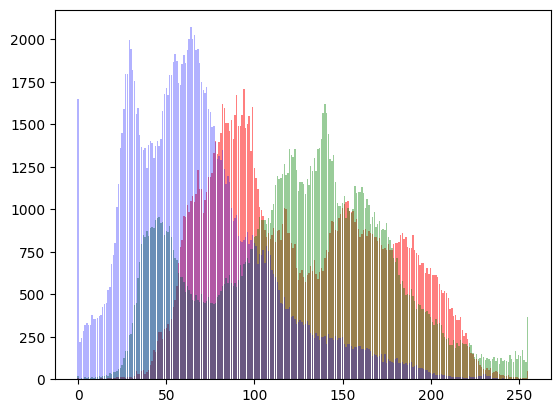

In [ ]:
pl = im.histogram()
plt.bar(range(256), pl[:256], color='r', alpha=0.5) # red channel with 50% transparency for first 256 values
plt.bar(range(256), pl[256:2*256], color='g', alpha=0.4) # green channel with 40% transparency for next 256 values
plt.bar(range(256), pl[2*256:], color='b', alpha=0.3) # blue channel with 30% transparency for last 256 values
plt.show()

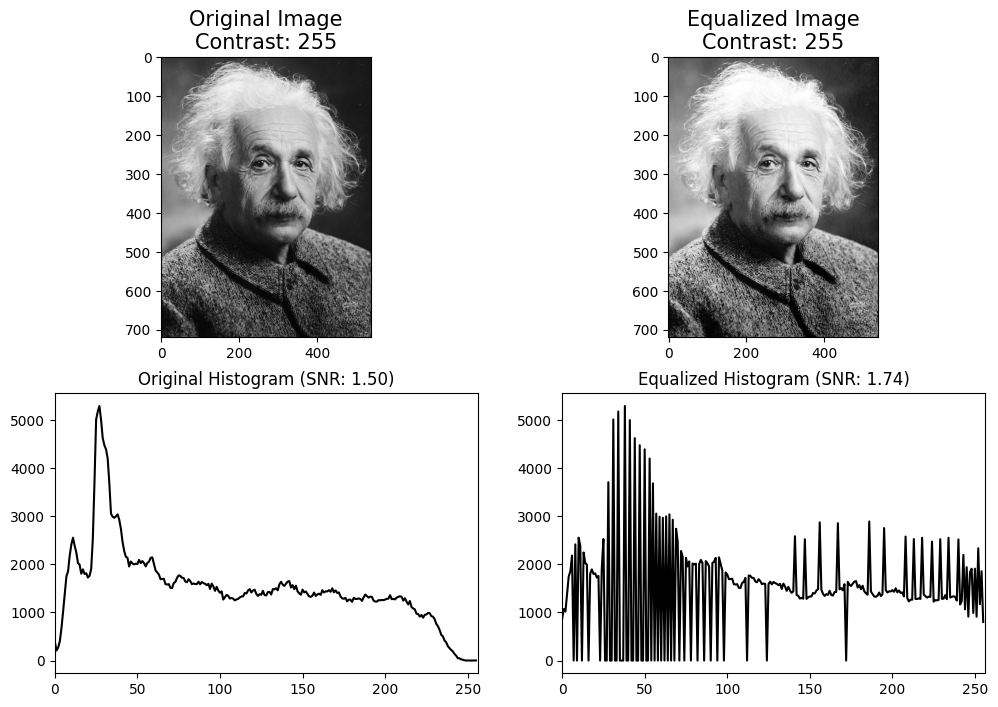

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load a grayscale image
image = cv2.imread('einstein.jpg', cv2.IMREAD_GRAYSCALE) #read the image as grayscale

# Apply histogram equalization
equalized_image = cv2.equalizeHist(image) #enhance the constrast of the image by applying the histogram equalization

# Calculate histograms for the original and equalized images
hist_original = cv2.calcHist([image], [0], None, [256], [0, 256])
hist_equalized = cv2.calcHist([equalized_image], [0], None, [256], [0, 256])

# Calculate contrast as max - min pixel value
contrast_original = np.max(image) - np.min(image)  # Contrast for original image
contrast_equalized = np.max(equalized_image) - np.min(equalized_image)  # Contrast for equalized image

# Plot the original and equalized images along with their histograms
plt.figure(figsize=(12, 8))

# Display original image with contrast value in the title
plt.subplot(2, 2, 1)
plt.title(f'Original Image\nContrast: {contrast_original}', size=15)
plt.imshow(image, cmap='gray')

# Display equalized image with contrast value in the title
plt.subplot(2, 2, 2)
plt.title(f'Equalized Image\nContrast: {contrast_equalized}', size=15)
plt.imshow(equalized_image, cmap='gray')

# Display histogram of original image
plt.subplot(2, 2, 3)
plt.title(f'Original Histogram (SNR: {original_snr:.2f})')
plt.plot(hist_original, color='black')
plt.xlim([0, 256])

# Display histogram of equalized image
plt.subplot(2, 2, 4)
plt.title(f'Equalized Histogram (SNR: {equalized_snr:.2f})')
plt.plot(hist_equalized, color='black')
plt.xlim([0, 256])

plt.show()


### Histogram equalization of RGB image

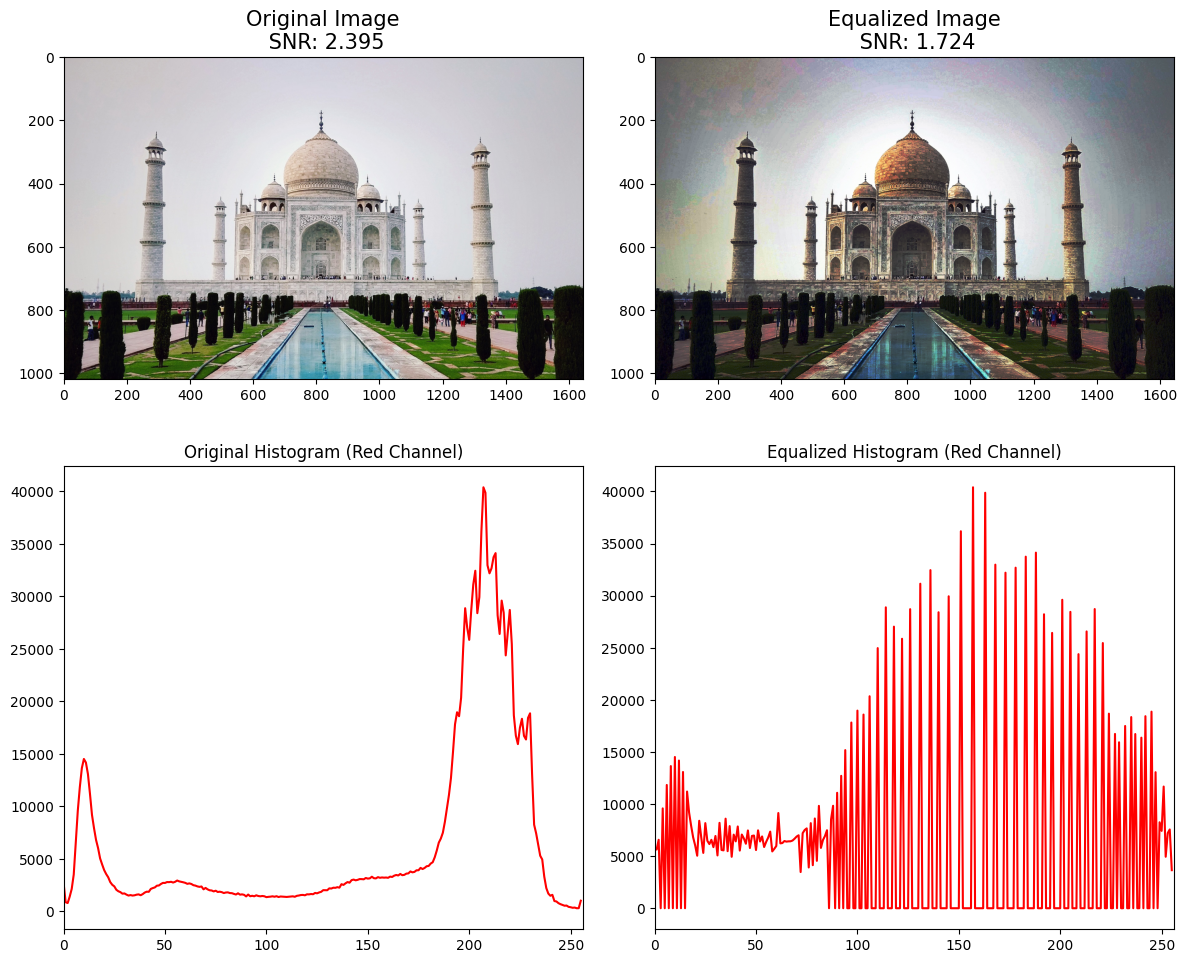

In [ ]:
# Load an RGB image
image = cv2.imread('tajmahal.jpg')  # Load image in BGR color format

# Convert the image from BGR to RGB (OpenCV loads images in BGR by default)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Split the image into three channels: R, G, B
r, g, b = cv2.split(image_rgb)

# Apply histogram equalization to each channel
r_eq = cv2.equalizeHist(r)
g_eq = cv2.equalizeHist(g)
b_eq = cv2.equalizeHist(b)

# Merge the equalized channels back into one image
equalized_image_rgb = cv2.merge([r_eq, g_eq, b_eq])

# Calculate histograms for the original and equalized images for each channel
hist_original_r = cv2.calcHist([r], [0], None, [256], [0, 256])
hist_equalized_r = cv2.calcHist([r_eq], [0], None, [256], [0, 256])

hist_original_g = cv2.calcHist([g], [0], None, [256], [0, 256])
hist_equalized_g = cv2.calcHist([g_eq], [0], None, [256], [0, 256])

hist_original_b = cv2.calcHist([b], [0], None, [256], [0, 256])
hist_equalized_b = cv2.calcHist([b_eq], [0], None, [256], [0, 256])

# Calculate SNR for both images
snr_original = signaltonoise(image_rgb, axis=None)
snr_equalized_image = signaltonoise(equalized_image_rgb, axis=None)

# Plot the original and equalized images along with their histograms
plt.figure(figsize=(12, 10))

# Display original image with contrast value in the title
plt.subplot(2, 2, 1)
plt.title(f'Original Image\n SNR: {snr_original:.3f}', size=15)
plt.imshow(image_rgb)

# Display equalized image with contrast value in the title
plt.subplot(2, 2, 2)
plt.title(f'Equalized Image\n SNR: {snr_equalized_image:.3f}', size=15)
plt.imshow(equalized_image_rgb)

# Display histogram of original red channel
plt.subplot(2, 2, 3)
plt.title('Original Histogram (Red Channel)')
plt.plot(hist_original_r, color='red')
plt.xlim([0, 256])

# Display histogram of equalized red channel
plt.subplot(2, 2, 4)
plt.title('Equalized Histogram (Red Channel)')
plt.plot(hist_equalized_r, color='red')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

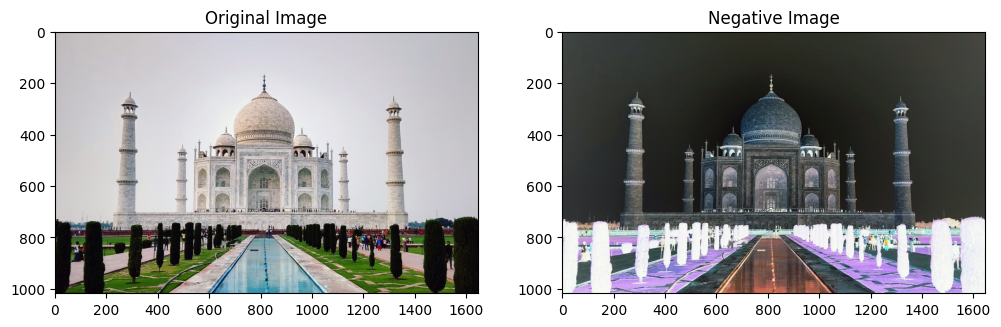

In [ ]:
# Load the image (ensure the path to your parrot image is correct)
image = cv2.imread('tajmahal.jpg')

# Convert to RGB from BGR (if using OpenCV, which loads images in BGR by default)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Generate the negative of the image by subtracting from 255
negative_image = 255 - image_rgb

# Display the original and negative images side by side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(negative_image)
plt.title('Negative Image')

plt.show()
